In [4]:
from itertools import chain

import numpy as np
import matplotlib.pyplot as plt

import itertools

from pathlib import Path

from jinja2.nodes import Dict

from embed_data import EmbeddingTrainingMode

In [5]:
EMBED_BASE_DATA_DIR = Path("./embed_results")
SUBDIR_PATH = "dim_{dim}/radius_{radius}"

In [6]:
RADIUS = 1.0  # only analyzed unit hyperspheres
DIMS = [1, 2, 3, 4]
TRAINING_MODES = [
    # use_intrinsic_coords, mode
    (False, EmbeddingTrainingMode.TRAIN_NO_ENC_DEC_STREAM),
    (True, EmbeddingTrainingMode.TRAIN_NO_ENC_DEC_STREAM),
    (True, EmbeddingTrainingMode.TRAIN_EXTRINSIC_ENC_DEC_STREAM),
    (True, EmbeddingTrainingMode.TRAIN_WITH_VEL_ENC_STREAM),
    (True, EmbeddingTrainingMode.TRAIN_WOUT_VEL_ENC_STREAM),
]

# NOTE: these do not correspond to the enum values and are only labels for the above list
TRAINING_MODE_LABELS = [
    "Ambient (None)",
    "Intrinsic (None)",
    "Intrinsic (Extrinsic)",
    "Intrinsic (Pos./Vel. Reconstr.)",
    "Intrinsic (Pos. Reconstr.)"
]
GEOM_LOSS_MODES = [
    # (degen_submatrix_penalty)
    None,
    (0.1,)
]


def get_training_cfg(use_intrinsic_coords, mode_idx) -> int:
    for idx, cfg in enumerate(TRAINING_MODES):
        if cfg[0] == use_intrinsic_coords and cfg[1].value == mode_idx:
            return idx
    raise ValueError("configuration not found")

In [7]:
def load_old_format(numpy_loaded) -> Dict:
    old_run = {
        "n": numpy_loaded["n"],
        "intrin_dim": numpy_loaded["intrin_dim"],
        "learn_extrin_dim": numpy_loaded["learn_extrin_dim"],
        "use_intrinsic_coords": numpy_loaded["use_intrinsic_pipeline_inputs"],
        # properties to examine
        "mode": numpy_loaded["mode"].item().value,  # enum number value
        "use_prev_state": numpy_loaded["with_prev_state"],
        "sparsity_penalty": numpy_loaded["sparsity_penalty"],
        "degen_submatrix_penalty": None,  # not used in this case
        # histories
        "train_batch_pipeline_loss_hist": numpy_loaded["train_batch_pipeline_loss_hist_numpy"],
        "train_batch_dec_enc_loss_hist": numpy_loaded["train_batch_dec_enc_loss_hist_numpy"],
        "train_batch_sparsity_loss_hist": numpy_loaded["train_batch_sparsity_loss_hist_numpy"],
        "train_batch_dec_geom_compat_loss_hist": None,
        "train_batch_enc_geom_compat_loss_hist": None,
        "train_batch_smooth_embed_loss_hist": None,
        "valid_batch_pipeline_loss_hist": numpy_loaded["valid_batch_pipeline_loss_hist_numpy"],
    }
    return old_run


def load_new_format(numpy_loaded) -> Dict:
    metric_compatibility = numpy_loaded["metric_compatibility"].item()
    degen_submatrix_penalty = metric_compatibility

    new_run = {
        "n": numpy_loaded["n"],
        "intrin_dim": numpy_loaded["intrin_dim"],
        "learn_extrin_dim": numpy_loaded["learn_extrin_dim"],
        "use_intrinsic_coords": numpy_loaded["use_intrinsic_pipeline_inputs"],
        # properties to examine
        "mode": numpy_loaded["mode"].item().value,  # enum number value
        "use_prev_state": numpy_loaded["with_prev_state"],
        "sparsity_penalty": None,  # not used in  this case
        "degen_submatrix_penalty": degen_submatrix_penalty,
        # histories
        "train_batch_pipeline_loss_hist": numpy_loaded["train_batch_pipeline_loss_hist_numpy"],
        "train_batch_dec_enc_loss_hist": numpy_loaded["train_batch_dec_enc_loss_hist_numpy"],
        "train_batch_sparsity_loss_hist": None,
        "train_batch_dec_geom_compat_loss_hist": numpy_loaded["train_batch_dec_geom_compat_loss_hist_numpy"],
        "train_batch_enc_geom_compat_loss_hist": numpy_loaded["train_batch_enc_geom_compat_loss_hist_numpy"],
        "train_batch_smooth_embed_loss_hist": numpy_loaded["train_batch_smooth_embed_loss_hist_numpy"],
        "valid_batch_pipeline_loss_hist": numpy_loaded["valid_batch_pipeline_loss_hist_numpy"],
    }
    return new_run


def load_run(numpy_loaded) -> Dict:
    if "sparsity_penalty" in numpy_loaded.files:
        run = load_old_format(numpy_loaded)
    else:
        run = load_new_format(numpy_loaded)

    # performs some statistics
    train_max_batch_loss_hist = np.max(run["train_batch_pipeline_loss_hist"], axis=1)
    train_min_batch_loss_hist = np.min(run["train_batch_pipeline_loss_hist"], axis=1)
    train_mean_batch_loss_hist = np.mean(run["train_batch_pipeline_loss_hist"], axis=1)

    valid_max_batch_loss_hist = np.max(run["valid_batch_pipeline_loss_hist"], axis=1)
    valid_min_batch_loss_hist = np.min(run["valid_batch_pipeline_loss_hist"], axis=1)
    valid_mean_batch_loss_hist = np.mean(run["valid_batch_pipeline_loss_hist"], axis=1)

    run.update({
        "train_max_batch_loss_hist": train_max_batch_loss_hist,
        "train_min_batch_loss_hist": train_min_batch_loss_hist,
        "train_mean_batch_loss_hist": train_mean_batch_loss_hist,
        "valid_max_batch_loss_hist": valid_max_batch_loss_hist,
        "valid_min_batch_loss_hist": valid_min_batch_loss_hist,
        "valid_mean_batch_loss_hist": valid_mean_batch_loss_hist,
    })

    return run

In [8]:
# load all the training results
# NOTE: for convenience we will separate the training data into the encoder scheme training with and without the geometric loss

training_data = []
training_data_with_geom_loss = []

for dim in DIMS:
    data_dir = EMBED_BASE_DATA_DIR / SUBDIR_PATH.format(
        dim=dim,
        radius=RADIUS,
    )

    no_geom_loss_data_dir = data_dir / "no_geom_loss"
    geom_loss_data_dir = data_dir / "geom_loss"

    for child in no_geom_loss_data_dir.iterdir():
        if child.is_dir() or not child.name.endswith(".npz"):
            continue

        numpy_loaded = np.load(child, allow_pickle=True)
        training_data.append(load_run(numpy_loaded))

    for child in geom_loss_data_dir.iterdir():
        if child.is_dir() or not child.name.endswith(".npz"):
            continue

        numpy_loaded = np.load(child, allow_pickle=True)
        training_data_with_geom_loss.append(load_run(numpy_loaded))
    pass

Dim: 4
training_cfg_idx: 0, dim: 4, use_prev_state: False
Dim: 4
training_cfg_idx: 1, dim: 4, use_prev_state: False
Dim: 4
training_cfg_idx: 2, dim: 4, use_prev_state: False
Dim: 4
training_cfg_idx: 3, dim: 4, use_prev_state: False
Dim: 4
training_cfg_idx: 4, dim: 4, use_prev_state: False


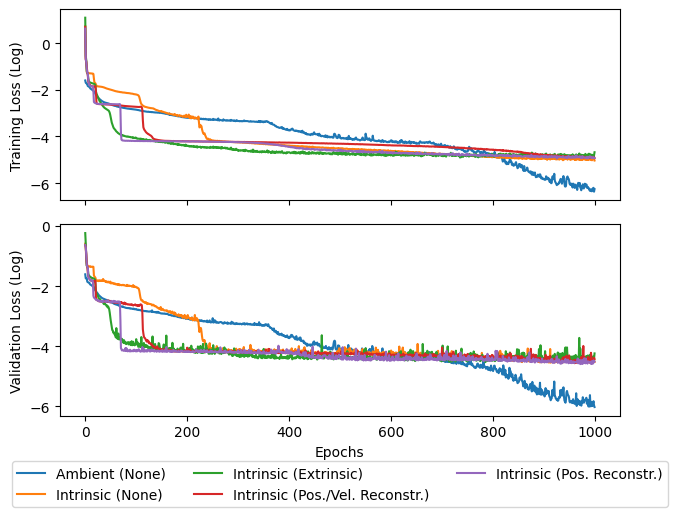

In [35]:
# display the results of each approach without inclusion of previous state
fig, (train_ax, valid_ax) = plt.subplots(2, 1)

data_no_prev_state = list(filter(lambda data: not data["use_prev_state"] and data["n"] == 4, training_data))
data_no_prev_state.sort(key=lambda data: get_training_cfg(data["use_intrinsic_coords"], data["mode"]))

for data in data_no_prev_state:
    training_cfg_idx = get_training_cfg(data["use_intrinsic_coords"], data["mode"])
    # if training_cfg_idx == 0:
    #     continue

    title = f"Dim: {data["n"]}"
    print(title)
    # train_ax.set_title(title)

    print(f"training_cfg_idx: {training_cfg_idx}, dim: {data["n"]}, use_prev_state: {data["use_prev_state"]}")

    train_ax.plot(np.log(data["train_mean_batch_loss_hist"]), label=TRAINING_MODE_LABELS[training_cfg_idx])
    valid_ax.plot(np.log(data["valid_mean_batch_loss_hist"]), label=TRAINING_MODE_LABELS[training_cfg_idx])

train_ax.set_ylabel("Training Loss (Log)")
train_ax.tick_params(labelbottom=False)
valid_ax.set_ylabel("Validation Loss (Log)")
valid_ax.set_xlabel("Epochs")

plt.tight_layout()
# train_ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
valid_ax.legend(
    # bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    loc='upper center',
    bbox_to_anchor=(0.5, -0.2),  # move below plot
    ncol=3)

training_cfg_idx: 0, dim: 3, use_prev_state: True
training_cfg_idx: 1, dim: 3, use_prev_state: True
training_cfg_idx: 2, dim: 3, use_prev_state: True
training_cfg_idx: 3, dim: 3, use_prev_state: True
training_cfg_idx: 4, dim: 3, use_prev_state: True


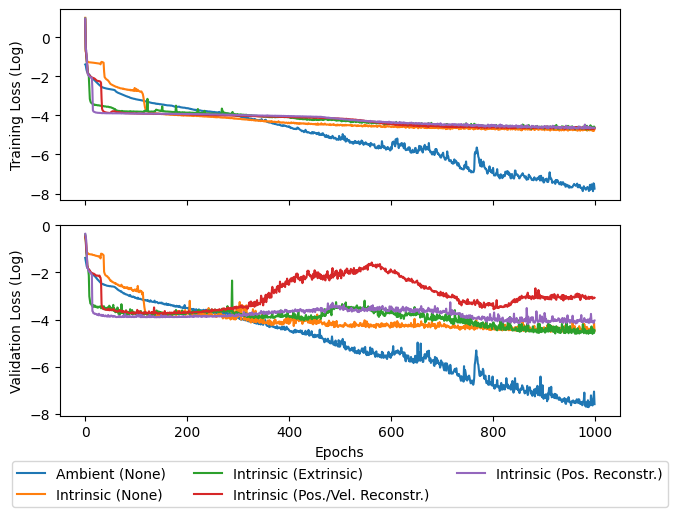

In [38]:
# display the results of each approach with inclusion of previous state
fig, (train_ax, valid_ax) = plt.subplots(2, 1)

data_no_prev_state = list(filter(lambda data: data["use_prev_state"] and data["n"] == 3, training_data))
data_no_prev_state.sort(key=lambda data: get_training_cfg(data["use_intrinsic_coords"], data["mode"]))

for data in data_no_prev_state:
    training_cfg_idx = get_training_cfg(data["use_intrinsic_coords"], data["mode"])

    # NOTE: uncomment to disable plotting of ambient
    # if training_cfg_idx == 0:
    #     continue

    title = f"Dim: {data["n"]}"
    # train_ax.set_title(title)

    print(f"training_cfg_idx: {training_cfg_idx}, dim: {data["n"]}, use_prev_state: {data["use_prev_state"]}")

    train_ax.plot(np.log(data["train_mean_batch_loss_hist"]), label=TRAINING_MODE_LABELS[training_cfg_idx])
    valid_ax.plot(np.log(data["valid_mean_batch_loss_hist"]), label=TRAINING_MODE_LABELS[training_cfg_idx])

train_ax.set_ylabel("Training Loss (Log)")
train_ax.tick_params(labelbottom=False)
valid_ax.set_ylabel("Validation Loss (Log)")
valid_ax.set_xlabel("Epochs")

plt.tight_layout()
valid_ax.legend(
    # bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    loc='upper center',
    bbox_to_anchor=(0.5, -0.2),  # move below plot
    ncol=3)
# train_ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

training_cfg_idx: 0, dim: 3, use_prev_state: False
training_cfg_idx: 1, dim: 3, use_prev_state: False
training_cfg_idx: 2, dim: 3, use_prev_state: False
training_cfg_idx: 3, dim: 3, use_prev_state: False
training_cfg_idx: 4, dim: 3, use_prev_state: False


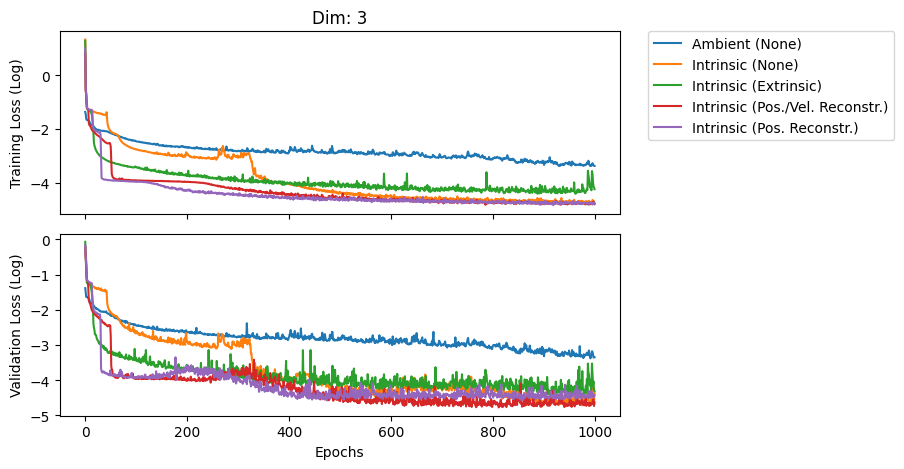

In [36]:
# display the results of each approach without inclusion of previous state but with inclusion of the geometric jacobian constraint
fig, (train_ax, valid_ax) = plt.subplots(2, 1)

data_no_prev_state = list(
    filter(lambda data: not data["use_prev_state"] and data["n"] == 3, training_data_with_geom_loss))
data_no_prev_state.sort(key=lambda data: get_training_cfg(data["use_intrinsic_coords"], data["mode"]))

for data in data_no_prev_state:
    training_cfg_idx = get_training_cfg(data["use_intrinsic_coords"], data["mode"])
    # if training_cfg_idx == 0:
    #     continue

    title = f"Dim: {data["n"]}"
    train_ax.set_title(title)

    print(f"training_cfg_idx: {training_cfg_idx}, dim: {data["n"]}, use_prev_state: {data["use_prev_state"]}")

    train_ax.plot(np.log(data["train_mean_batch_loss_hist"]), label=TRAINING_MODE_LABELS[training_cfg_idx])
    valid_ax.plot(np.log(data["valid_mean_batch_loss_hist"]))

train_ax.set_ylabel("Training Loss (Log)")
train_ax.tick_params(labelbottom=False)
valid_ax.set_ylabel("Validation Loss (Log)")
valid_ax.set_xlabel("Epochs")

plt.tight_layout()
train_ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

training_cfg_idx: 0, dim: 4, use_prev_state: True
training_cfg_idx: 1, dim: 4, use_prev_state: True
training_cfg_idx: 2, dim: 4, use_prev_state: True
training_cfg_idx: 3, dim: 4, use_prev_state: True
training_cfg_idx: 4, dim: 4, use_prev_state: True


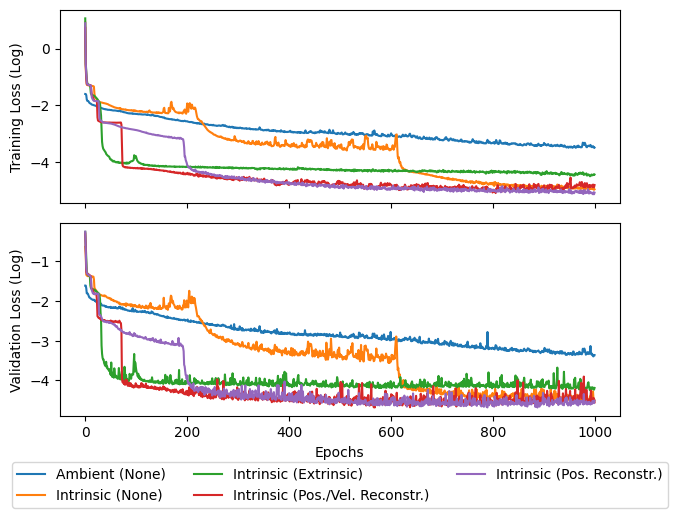

In [39]:
# display the results of each approach with inclusion of previous state but with inclusion of the geometric jacobian constraint
fig, (train_ax, valid_ax) = plt.subplots(2, 1)

data_no_prev_state = list(filter(lambda data: data["use_prev_state"] and data["n"] == 47, training_data_with_geom_loss))
data_no_prev_state.sort(key=lambda data: get_training_cfg(data["use_intrinsic_coords"], data["mode"]))

for data in data_no_prev_state:
    training_cfg_idx = get_training_cfg(data["use_intrinsic_coords"], data["mode"])
    # if training_cfg_idx == 0:
    #     continue

    title = f"Dim: {data["n"]}"
    # train_ax.set_title(title)

    print(f"training_cfg_idx: {training_cfg_idx}, dim: {data["n"]}, use_prev_state: {data["use_prev_state"]}")

    train_ax.plot(np.log(data["train_mean_batch_loss_hist"]), label=TRAINING_MODE_LABELS[training_cfg_idx])
    valid_ax.plot(np.log(data["valid_mean_batch_loss_hist"]), label=TRAINING_MODE_LABELS[training_cfg_idx])

train_ax.set_ylabel("Training Loss (Log)")
train_ax.tick_params(labelbottom=False)
valid_ax.set_ylabel("Validation Loss (Log)")
valid_ax.set_xlabel("Epochs")

plt.tight_layout()
valid_ax.legend(
    # bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    loc='upper center',
    bbox_to_anchor=(0.5, -0.2),  # move below plot
    ncol=3)

In [13]:
# compute statistics for the final iterations (once fully trained)

# NOTE: training_modes, using_prev_state, using_geom_loss, dims
avg_final_mean_train_losses = np.zeros((len(TRAINING_MODES), 2, 2, len(DIMS)))
std_final_mean_train_losses = np.zeros((len(TRAINING_MODES), 2, 2, len(DIMS)))
avg_final_mean_valid_losses = np.zeros((len(TRAINING_MODES), 2, 2, len(DIMS)))
std_final_mean_valid_losses = np.zeros((len(TRAINING_MODES), 2, 2, len(DIMS)))

avg_final_max_train_losses = np.zeros((len(TRAINING_MODES), 2, 2, len(DIMS)))
std_final_max_train_losses = np.zeros((len(TRAINING_MODES), 2, 2, len(DIMS)))
avg_final_max_valid_losses = np.zeros((len(TRAINING_MODES), 2, 2, len(DIMS)))
std_final_max_valid_losses = np.zeros((len(TRAINING_MODES), 2, 2, len(DIMS)))

EPOCHS_TO_AVG = 100

for data in itertools.chain(training_data, training_data_with_geom_loss):
    mode_idx = get_training_cfg(data["use_intrinsic_coords"], data["mode"])
    prev_state_idx = 1 if data["use_prev_state"] else 0
    geom_loss_idx = 1 if data["degen_submatrix_penalty"] is not None else 0
    dim_idx = DIMS.index(data["n"])

    final_mean_train_losses = data["train_mean_batch_loss_hist"][-EPOCHS_TO_AVG:]
    final_mean_valid_losses = data["valid_mean_batch_loss_hist"][-EPOCHS_TO_AVG:]
    final_max_train_losses = data["train_max_batch_loss_hist"][-EPOCHS_TO_AVG:]
    final_max_valid_losses = data["valid_max_batch_loss_hist"][-EPOCHS_TO_AVG:]

    # takes average
    avg_final_mean_train_losses[mode_idx, prev_state_idx, geom_loss_idx, dim_idx] = np.mean(final_mean_train_losses)
    std_final_mean_train_losses[mode_idx, prev_state_idx, geom_loss_idx, dim_idx] = np.std(final_mean_train_losses)
    avg_final_mean_valid_losses[mode_idx, prev_state_idx, geom_loss_idx, dim_idx] = np.mean(
        final_mean_valid_losses
    )
    std_final_mean_valid_losses[mode_idx, prev_state_idx, geom_loss_idx, dim_idx] = np.std(
        final_mean_valid_losses
    )

    avg_final_max_train_losses[mode_idx, prev_state_idx, geom_loss_idx, dim_idx] = np.mean(final_max_train_losses)
    std_final_max_train_losses[mode_idx, prev_state_idx, geom_loss_idx, dim_idx] = np.std(final_max_train_losses)
    avg_final_max_valid_losses[mode_idx, prev_state_idx, geom_loss_idx, dim_idx] = np.mean(
        final_max_valid_losses
    )
    std_final_max_valid_losses[mode_idx, prev_state_idx, geom_loss_idx, dim_idx] = np.std(
        final_max_valid_losses
    )



prev_state_idx: 0
prev_state_idx: 1


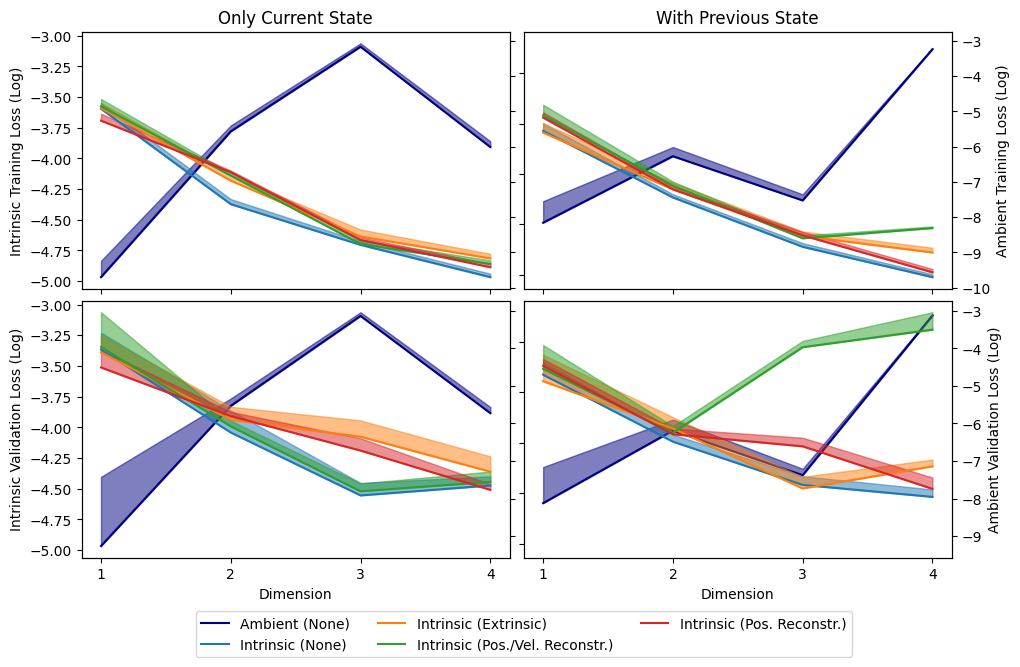

In [14]:
# presents the average mean steady-state train/valid loss vs dimension
# NOTE: this cell handles presentation of the losses vs dimension for the cases without geometry jacobian loss
fig, axes = plt.subplots(2, 2, constrained_layout=False, figsize=(10, 6), sharex='row', sharey='col')
twins = [[ax.twinx() for ax in row] for row in axes]

for prev_state_idx in range(2):
    print(f"prev_state_idx: {prev_state_idx}")

    train_ax, valid_ax = axes[0, prev_state_idx], axes[1, prev_state_idx]
    train_ax_twin, valid_ax_twin = twins[0][prev_state_idx], twins[1][prev_state_idx]

    # renders so we place the secondary axis (with extrinsic data) below the intrinsic data
    train_ax.patch.set_visible(False)
    train_ax_twin.set_zorder(train_ax.get_zorder() - 1)
    valid_ax.patch.set_visible(False)
    valid_ax_twin.set_zorder(valid_ax.get_zorder() - 1)

    title = "Only Current State" if prev_state_idx == 0 else "With Previous State"
    train_ax.set_title(title)

    for training_mode_idx in range(len(TRAINING_MODES)):
        # print(f"training_mode_idx: {training_mode_idx}")

        label = TRAINING_MODE_LABELS[training_mode_idx]

        # gets the training/validation data for the current mode and prev state config.
        # NOTE: the 0 in this case refers to having the geometry jacobian loss condition disabled
        mode_mean_train_data = avg_final_mean_train_losses[training_mode_idx, prev_state_idx, 0, :]
        mode_mean_std_train_data = std_final_mean_train_losses[training_mode_idx, prev_state_idx, 0, :]
        mode_max_train_data = avg_final_max_train_losses[training_mode_idx, prev_state_idx, 0, :]
        mode_max_std_train_data = std_final_max_train_losses[training_mode_idx, prev_state_idx, 0, :]

        mode_mean_valid_data = avg_final_mean_valid_losses[training_mode_idx, prev_state_idx, 0, :]
        mode_mean_std_valid_data = std_final_mean_valid_losses[training_mode_idx, prev_state_idx, 0, :]
        mode_max_valid_data = avg_final_max_valid_losses[training_mode_idx, prev_state_idx, 0, :]
        mode_max_std_valid_data = std_final_max_valid_losses[training_mode_idx, prev_state_idx, 0, :]

        # performs a check to see if this is the ambient mode so we can color the line red
        is_ambient = training_mode_idx == 0
        # print(f"is_ambient: {is_ambient}")
        if is_ambient:
            sel_train_ax, sel_valid_ax = train_ax_twin, valid_ax_twin
        else:
            sel_train_ax, sel_valid_ax = train_ax, valid_ax
        color = "navy" if is_ambient else None

        # print(np.log(mode_mean_train_data))

        train_line, = sel_train_ax.plot(DIMS, np.log(mode_mean_train_data), label=label, color=color)
        sel_train_ax.fill_between(DIMS,
                                  np.log(mode_mean_train_data),
                                  np.log(mode_mean_train_data + mode_mean_std_train_data),
                                  # np.log(mode_max_train_data),
                                  alpha=0.5, color=train_line.get_color())

        valid_line, = sel_valid_ax.plot(DIMS, np.log(mode_mean_valid_data), label=label, color=color)
        sel_valid_ax.fill_between(DIMS,
                                  np.log(mode_mean_valid_data),
                                  np.log(mode_mean_valid_data + mode_mean_std_valid_data),
                                  # np.log(mode_max_valid_data),
                                  alpha=0.5, color=valid_line.get_color())

    train_ax.set_xticks(DIMS, DIMS)
    valid_ax.set_xticks(DIMS, DIMS)

for ax in axes[:, 1:].flatten():
    ax.tick_params(labelleft=False)
for ax in axes[0, :].flatten():
    ax.tick_params(labelbottom=False)

for row in twins:
    min_twin_ylim = min(ax.get_ylim()[0] for ax in row)
    max_twin_ylim = max(ax.get_ylim()[1] for ax in row)

    num_in_row = len(row)
    for i, ax in enumerate(row):
        ax.set_ylim((min_twin_ylim, max_twin_ylim))
        if i != num_in_row - 1:
            ax.tick_params(labelright=False)

axes[0, 0].set_ylabel("Intrinsic Training Loss (Log)")
axes[1, 0].set_ylabel("Intrinsic Validation Loss (Log)")

twins[0][1].set_ylabel("Ambient Training Loss (Log)")
twins[1][1].set_ylabel("Ambient Validation Loss (Log)")

axes[1, 0].set_xlabel("Dimension")
axes[1, 1].set_xlabel("Dimension")

plt.tight_layout(pad=0.3)

train_leg_lines, train_leg_labels = axes[0, 0].get_legend_handles_labels()
twin_train_leg_lines, twin_train_leg_labels = twins[0][0].get_legend_handles_labels()

# NOTE: twin handles obtained first so ambient first then intrinsic and then intrinsic trained on ambient
axes[1, 1].legend(twin_train_leg_lines + train_leg_lines,
                  twin_train_leg_labels + train_leg_labels,
                  # bbox_to_anchor=(1.15, 1), loc='upper left', borderaxespad=0.)
                  loc='upper center',
                  bbox_to_anchor=(0.0, -0.18),  # move below plot
                  ncol=3)

plt.show()

prev_state_idx: 0
prev_state_idx: 1


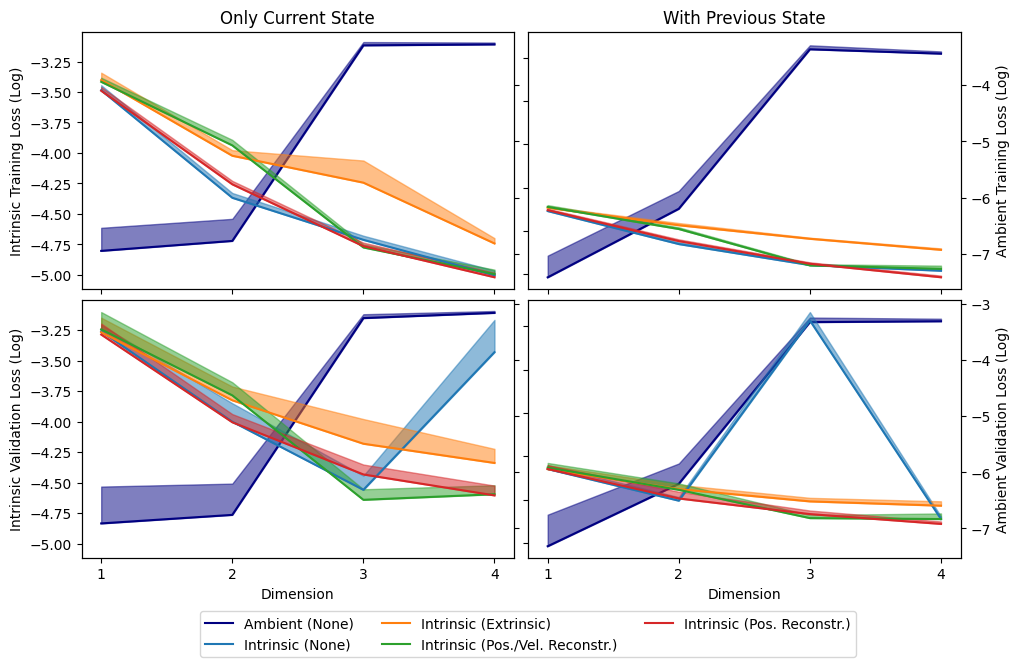

In [15]:
# presents the average mean steady-state train/valid loss vs dimension
# NOTE: this cell handles presentation of the losses vs dimension for the cases with geometry jacobian loss
fig, axes = plt.subplots(2, 2, constrained_layout=False, figsize=(10, 6), sharex='row', sharey='col')
twins = [[ax.twinx() for ax in row] for row in axes]

for prev_state_idx in range(2):
    print(f"prev_state_idx: {prev_state_idx}")

    train_ax, valid_ax = axes[0, prev_state_idx], axes[1, prev_state_idx]
    train_ax_twin, valid_ax_twin = twins[0][prev_state_idx], twins[1][prev_state_idx]

    # renders so we place the secondary axis (with extrinsic data) below the intrinsic data
    train_ax.patch.set_visible(False)
    train_ax_twin.set_zorder(train_ax.get_zorder() - 1)
    valid_ax.patch.set_visible(False)
    valid_ax_twin.set_zorder(valid_ax.get_zorder() - 1)

    title = "Only Current State" if prev_state_idx == 0 else "With Previous State"
    train_ax.set_title(title)

    for training_mode_idx in range(len(TRAINING_MODES)):
        # print(f"training_mode_idx: {training_mode_idx}")

        label = TRAINING_MODE_LABELS[training_mode_idx]

        # gets the training/validation data for the current mode and prev state config.
        # NOTE: the 1 in this case refers to having the geometry jacobian loss condition enabled
        mode_mean_train_data = avg_final_mean_train_losses[training_mode_idx, prev_state_idx, 1, :]
        mode_mean_std_train_data = std_final_mean_train_losses[training_mode_idx, prev_state_idx, 1, :]
        mode_max_train_data = avg_final_max_train_losses[training_mode_idx, prev_state_idx, 1, :]
        mode_max_std_train_data = std_final_max_train_losses[training_mode_idx, prev_state_idx, 1, :]

        mode_mean_valid_data = avg_final_mean_valid_losses[training_mode_idx, prev_state_idx, 1, :]
        mode_mean_std_valid_data = std_final_mean_valid_losses[training_mode_idx, prev_state_idx, 1, :]
        mode_max_valid_data = avg_final_max_valid_losses[training_mode_idx, prev_state_idx, 1, :]
        mode_max_std_valid_data = std_final_max_valid_losses[training_mode_idx, prev_state_idx, 1, :]

        # performs a check to see if this is the ambient mode so we can color the line red
        is_ambient = training_mode_idx == 0
        # print(f"is_ambient: {is_ambient}")
        if is_ambient:
            sel_train_ax, sel_valid_ax = train_ax_twin, valid_ax_twin
        else:
            sel_train_ax, sel_valid_ax = train_ax, valid_ax
        color = "navy" if is_ambient else None

        # print(np.log(mode_mean_train_data))

        train_line, = sel_train_ax.plot(DIMS, np.log(mode_mean_train_data), label=label, color=color)
        sel_train_ax.fill_between(DIMS,
                                  np.log(mode_mean_train_data),
                                  np.log(mode_mean_train_data + mode_mean_std_train_data),
                                  # np.log(mode_max_train_data),
                                  alpha=0.5, color=train_line.get_color())

        valid_line, = sel_valid_ax.plot(DIMS, np.log(mode_mean_valid_data), label=label, color=color)
        sel_valid_ax.fill_between(DIMS,
                                  np.log(mode_mean_valid_data),
                                  np.log(mode_mean_valid_data + mode_mean_std_valid_data),
                                  # np.log(mode_max_valid_data),
                                  alpha=0.5, color=valid_line.get_color())

    train_ax.set_xticks(DIMS, DIMS)
    valid_ax.set_xticks(DIMS, DIMS)

for ax in axes[:, 1:].flatten():
    ax.tick_params(labelleft=False)
for ax in axes[0, :].flatten():
    ax.tick_params(labelbottom=False)

for row in twins:
    min_twin_ylim = min(ax.get_ylim()[0] for ax in row)
    max_twin_ylim = max(ax.get_ylim()[1] for ax in row)

    num_in_row = len(row)
    for i, ax in enumerate(row):
        ax.set_ylim((min_twin_ylim, max_twin_ylim))
        if i != num_in_row - 1:
            ax.tick_params(labelright=False)

axes[0, 0].set_ylabel("Intrinsic Training Loss (Log)")
axes[1, 0].set_ylabel("Intrinsic Validation Loss (Log)")

twins[0][1].set_ylabel("Ambient Training Loss (Log)")
twins[1][1].set_ylabel("Ambient Validation Loss (Log)")

axes[1, 0].set_xlabel("Dimension")
axes[1, 1].set_xlabel("Dimension")

plt.tight_layout(pad=0.3)

train_leg_lines, train_leg_labels = axes[0, 0].get_legend_handles_labels()
twin_train_leg_lines, twin_train_leg_labels = twins[0][0].get_legend_handles_labels()

# NOTE: twin handles obtained first so ambient first then intrinsic and then intrinsic trained on ambient
axes[1, 1].legend(twin_train_leg_lines + train_leg_lines,
                  twin_train_leg_labels + train_leg_labels,
                  # bbox_to_anchor=(1.15, 1), loc='upper left', borderaxespad=0.)
                  loc='upper center',
                  bbox_to_anchor=(0.0, -0.18),  # move below plot
                  ncol=3)

plt.show()

max
prev_state_idx: 0
prev_state_idx: 1


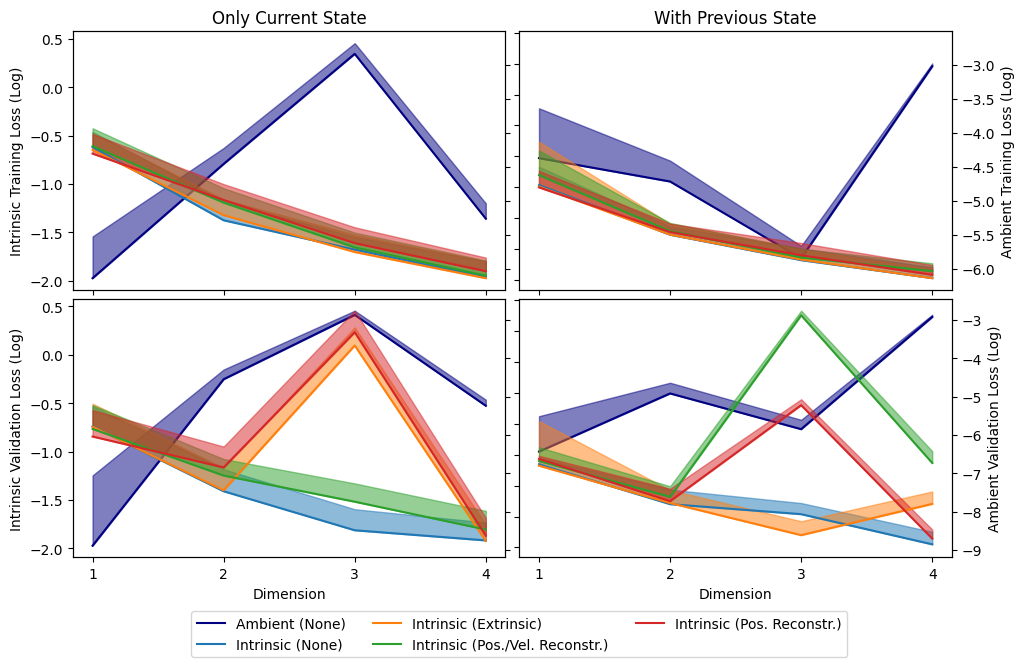

In [16]:
# presents the average max steady-state train/valid loss vs dimension
# NOTE: this cell handles presentation of the losses vs dimension for the cases without geometry jacobian loss
fig, axes = plt.subplots(2, 2, constrained_layout=False, figsize=(10, 6), sharex='row', sharey='col')
twins = [[ax.twinx() for ax in row] for row in axes]

print("max")

for prev_state_idx in range(2):
    print(f"prev_state_idx: {prev_state_idx}")

    train_ax, valid_ax = axes[0, prev_state_idx], axes[1, prev_state_idx]
    train_ax_twin, valid_ax_twin = twins[0][prev_state_idx], twins[1][prev_state_idx]

    # renders so we place the secondary axis (with extrinsic data) below the intrinsic data
    train_ax.patch.set_visible(False)
    train_ax_twin.set_zorder(train_ax.get_zorder() - 1)
    valid_ax.patch.set_visible(False)
    valid_ax_twin.set_zorder(valid_ax.get_zorder() - 1)

    title = "Only Current State" if prev_state_idx == 0 else "With Previous State"
    train_ax.set_title(title)

    for training_mode_idx in range(len(TRAINING_MODES)):
        # print(f"training_mode_idx: {training_mode_idx}")

        label = TRAINING_MODE_LABELS[training_mode_idx]

        # gets the training/validation data for the current mode and prev state config.
        # NOTE: the 0 in this case refers to having the geometry jacobian loss condition disabled
        mode_mean_train_data = avg_final_mean_train_losses[training_mode_idx, prev_state_idx, 0, :]
        mode_mean_std_train_data = std_final_mean_train_losses[training_mode_idx, prev_state_idx, 0, :]
        mode_max_train_data = avg_final_max_train_losses[training_mode_idx, prev_state_idx, 0, :]
        mode_max_std_train_data = std_final_max_train_losses[training_mode_idx, prev_state_idx, 0, :]

        mode_mean_valid_data = avg_final_mean_valid_losses[training_mode_idx, prev_state_idx, 0, :]
        mode_mean_std_valid_data = std_final_mean_valid_losses[training_mode_idx, prev_state_idx, 0, :]
        mode_max_valid_data = avg_final_max_valid_losses[training_mode_idx, prev_state_idx, 0, :]
        mode_max_std_valid_data = std_final_max_valid_losses[training_mode_idx, prev_state_idx, 0, :]

        # performs a check to see if this is the ambient mode so we can color the line red
        is_ambient = training_mode_idx == 0
        # print(f"is_ambient: {is_ambient}")
        if is_ambient:
            sel_train_ax, sel_valid_ax = train_ax_twin, valid_ax_twin
        else:
            sel_train_ax, sel_valid_ax = train_ax, valid_ax
        color = "navy" if is_ambient else None

        # print(np.log(mode_mean_train_data))

        train_line, = sel_train_ax.plot(DIMS, np.log(mode_max_train_data), label=label, color=color)
        sel_train_ax.fill_between(DIMS,
                                  np.log(mode_max_train_data),
                                  np.log(mode_max_train_data + mode_max_std_train_data),
                                  # np.log(mode_max_train_data),
                                  alpha=0.5, color=train_line.get_color())

        valid_line, = sel_valid_ax.plot(DIMS, np.log(mode_max_valid_data), label=label, color=color)
        sel_valid_ax.fill_between(DIMS,
                                  np.log(mode_max_valid_data),
                                  np.log(mode_max_valid_data + mode_max_std_valid_data),
                                  # np.log(mode_max_valid_data),
                                  alpha=0.5, color=valid_line.get_color())

    train_ax.set_xticks(DIMS, DIMS)
    valid_ax.set_xticks(DIMS, DIMS)

for ax in axes[:, 1:].flatten():
    ax.tick_params(labelleft=False)
for ax in axes[0, :].flatten():
    ax.tick_params(labelbottom=False)

for row in twins:
    min_twin_ylim = min(ax.get_ylim()[0] for ax in row)
    max_twin_ylim = max(ax.get_ylim()[1] for ax in row)

    num_in_row = len(row)
    for i, ax in enumerate(row):
        ax.set_ylim((min_twin_ylim, max_twin_ylim))
        if i != num_in_row - 1:
            ax.tick_params(labelright=False)

axes[0, 0].set_ylabel("Intrinsic Training Loss (Log)")
axes[1, 0].set_ylabel("Intrinsic Validation Loss (Log)")

twins[0][1].set_ylabel("Ambient Training Loss (Log)")
twins[1][1].set_ylabel("Ambient Validation Loss (Log)")

axes[1, 0].set_xlabel("Dimension")
axes[1, 1].set_xlabel("Dimension")

plt.tight_layout(pad=0.3)

train_leg_lines, train_leg_labels = axes[0, 0].get_legend_handles_labels()
twin_train_leg_lines, twin_train_leg_labels = twins[0][0].get_legend_handles_labels()

# NOTE: twin handles obtained first so ambient first then intrinsic and then intrinsic trained on ambient
axes[1, 1].legend(twin_train_leg_lines + train_leg_lines,
                  twin_train_leg_labels + train_leg_labels,
                  # bbox_to_anchor=(1.15, 1), loc='upper left', borderaxespad=0.)
                  loc='upper center',
                  bbox_to_anchor=(0.0, -0.18),  # move below plot
                  ncol=3)

plt.show()

max
prev_state_idx: 0
prev_state_idx: 1


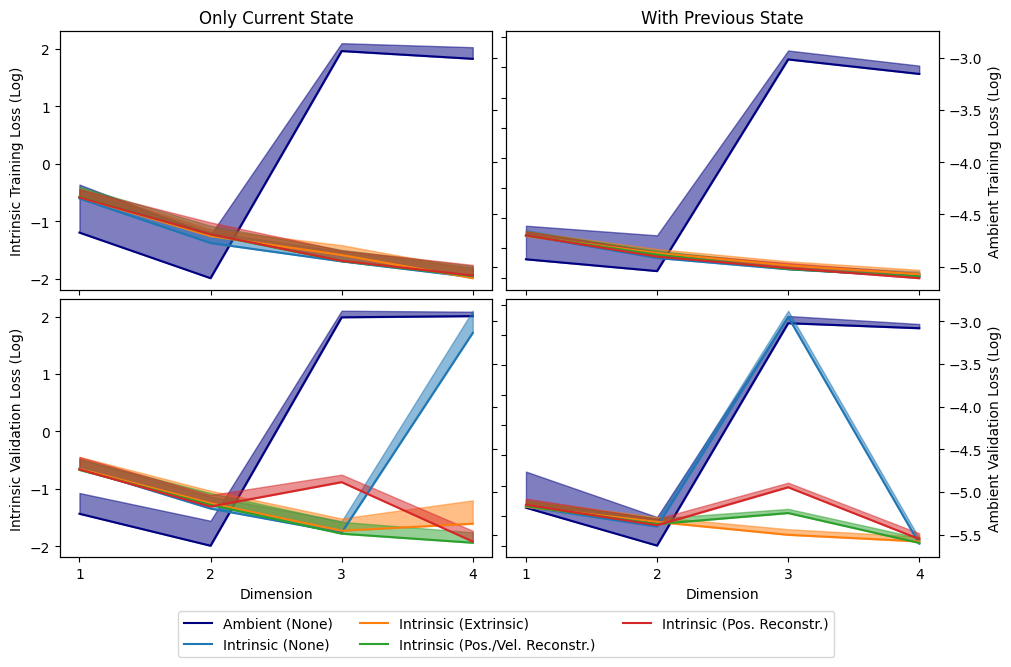

In [17]:
# presents the average max steady-state train/valid loss vs dimension
# NOTE: this cell handles presentation of the losses vs dimension for the cases with geometry jacobian loss
fig, axes = plt.subplots(2, 2, constrained_layout=False, figsize=(10, 6), sharex='row', sharey='col')
twins = [[ax.twinx() for ax in row] for row in axes]

print("max")

for prev_state_idx in range(2):
    print(f"prev_state_idx: {prev_state_idx}")

    train_ax, valid_ax = axes[0, prev_state_idx], axes[1, prev_state_idx]
    train_ax_twin, valid_ax_twin = twins[0][prev_state_idx], twins[1][prev_state_idx]

    # renders so we place the secondary axis (with extrinsic data) below the intrinsic data
    train_ax.patch.set_visible(False)
    train_ax_twin.set_zorder(train_ax.get_zorder() - 1)
    valid_ax.patch.set_visible(False)
    valid_ax_twin.set_zorder(valid_ax.get_zorder() - 1)

    title = "Only Current State" if prev_state_idx == 0 else "With Previous State"
    train_ax.set_title(title)

    for training_mode_idx in range(len(TRAINING_MODES)):
        # print(f"training_mode_idx: {training_mode_idx}")

        label = TRAINING_MODE_LABELS[training_mode_idx]

        # gets the training/validation data for the current mode and prev state config.
        # NOTE: the 1 in this case refers to having the geometry jacobian loss condition enabled
        mode_mean_train_data = avg_final_mean_train_losses[training_mode_idx, prev_state_idx, 1, :]
        mode_mean_std_train_data = std_final_mean_train_losses[training_mode_idx, prev_state_idx, 1, :]
        mode_max_train_data = avg_final_max_train_losses[training_mode_idx, prev_state_idx, 1, :]
        mode_max_std_train_data = std_final_max_train_losses[training_mode_idx, prev_state_idx, 1, :]

        mode_mean_valid_data = avg_final_mean_valid_losses[training_mode_idx, prev_state_idx, 1, :]
        mode_mean_std_valid_data = std_final_mean_valid_losses[training_mode_idx, prev_state_idx, 1, :]
        mode_max_valid_data = avg_final_max_valid_losses[training_mode_idx, prev_state_idx, 1, :]
        mode_max_std_valid_data = std_final_max_valid_losses[training_mode_idx, prev_state_idx, 1, :]

        # performs a check to see if this is the ambient mode so we can color the line red
        is_ambient = training_mode_idx == 0
        # print(f"is_ambient: {is_ambient}")
        if is_ambient:
            sel_train_ax, sel_valid_ax = train_ax_twin, valid_ax_twin
        else:
            sel_train_ax, sel_valid_ax = train_ax, valid_ax
        color = "navy" if is_ambient else None

        # print(np.log(mode_mean_train_data))

        train_line, = sel_train_ax.plot(DIMS, np.log(mode_max_train_data), label=label, color=color)
        sel_train_ax.fill_between(DIMS,
                                  np.log(mode_max_train_data),
                                  np.log(mode_max_train_data + mode_max_std_train_data),
                                  # np.log(mode_max_train_data),
                                  alpha=0.5, color=train_line.get_color())

        valid_line, = sel_valid_ax.plot(DIMS, np.log(mode_max_valid_data), label=label, color=color)
        sel_valid_ax.fill_between(DIMS,
                                  np.log(mode_max_valid_data),
                                  np.log(mode_max_valid_data + mode_max_std_valid_data),
                                  # np.log(mode_max_valid_data),
                                  alpha=0.5, color=valid_line.get_color())

    train_ax.set_xticks(DIMS, DIMS)
    valid_ax.set_xticks(DIMS, DIMS)

for ax in axes[:, 1:].flatten():
    ax.tick_params(labelleft=False)
for ax in axes[0, :].flatten():
    ax.tick_params(labelbottom=False)

for row in twins:
    min_twin_ylim = min(ax.get_ylim()[0] for ax in row)
    max_twin_ylim = max(ax.get_ylim()[1] for ax in row)

    num_in_row = len(row)
    for i, ax in enumerate(row):
        ax.set_ylim((min_twin_ylim, max_twin_ylim))
        if i != num_in_row - 1:
            ax.tick_params(labelright=False)

axes[0, 0].set_ylabel("Intrinsic Training Loss (Log)")
axes[1, 0].set_ylabel("Intrinsic Validation Loss (Log)")

twins[0][1].set_ylabel("Ambient Training Loss (Log)")
twins[1][1].set_ylabel("Ambient Validation Loss (Log)")

axes[1, 0].set_xlabel("Dimension")
axes[1, 1].set_xlabel("Dimension")

plt.tight_layout(pad=0.3)

train_leg_lines, train_leg_labels = axes[0, 0].get_legend_handles_labels()
twin_train_leg_lines, twin_train_leg_labels = twins[0][0].get_legend_handles_labels()

# NOTE: twin handles obtained first so ambient first then intrinsic and then intrinsic trained on ambient
axes[1, 1].legend(twin_train_leg_lines + train_leg_lines,
                  twin_train_leg_labels + train_leg_labels,
                  # bbox_to_anchor=(1.15, 1), loc='upper left', borderaxespad=0.)
                  loc='upper center',
                  bbox_to_anchor=(0.0, -0.18),  # move below plot
                  ncol=3)

plt.show()